# 🏥 Medical RAG Chatbot
### LangChain · LangGraph · Hugging Face · Wikipedia · FAISS

---

| Component | Technology |
|-----------|------------|
| 🤖 LLM | `HuggingFaceHub` — direct inference via API |
| 🧠 Embeddings | `sentence-transformers/all-MiniLM-L6-v2` (local) |
| 📚 Vector Store | FAISS (in-memory) |
| 🌐 Knowledge Base | Wikipedia via `wikipedia-api` |
| 🔗 Orchestration | LangGraph ReAct Agent |
| 🔧 Tools | RAG Retriever · Live Wikipedia · Symptom Checker |

## 📦 Step 1 — Install Dependencies

In [1]:
!pip install -q \
    langchain \
    langchain-core \
    langchain-community \
    langchain-huggingface \
    huggingface-hub \
    langgraph \
    sentence-transformers \
    faiss-cpu \
    wikipedia-api \
    python-dotenv \
    tiktoken \
    ipywidgets

print('✅ All packages installed!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests

## 🔑 Step 2 — Hugging Face API Token
> Get a free token → **https://huggingface.co/settings/tokens**

> ⚠️ Make sure your token has **Read** access and you have accepted the model license.

In [2]:
import os
from getpass import getpass

HF_TOKEN = getpass('🔑 Enter your Hugging Face API token: ')
os.environ['HUGGINGFACEHUB_API_TOKEN'] = HF_TOKEN

print('✅ Token loaded successfully!')

🔑 Enter your Hugging Face API token: ··········
✅ Token loaded successfully!


## 📥 Step 3 — Imports

In [3]:
import os
from typing import Annotated, List
from typing_extensions import TypedDict
from IPython.display import display, Image

# Hugging Face
from langchain_huggingface import HuggingFaceEmbeddings, ChatHuggingFace, HuggingFaceEndpoint

# LangChain core
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.tools import create_retriever_tool, tool
from langchain_core.documents import Document
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

# LangGraph
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

print('✅ All imports successful!')

/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


✅ All imports successful!


## 📚 Step 4 — Load Wikipedia Medical Knowledge Base

In [4]:
import wikipediaapi
from time import sleep

wiki = wikipediaapi.Wikipedia(language='en', user_agent='MediBot/1.0')

MEDICAL_TOPICS = [
    # Diseases
    'Diabetes mellitus', 'Hypertension', 'COVID-19', 'Cancer', 'Asthma',
    'Tuberculosis', 'Pneumonia', 'Influenza', 'Dengue fever', 'Malaria',
    'Heart disease', 'Stroke', 'Kidney failure', 'Liver disease', 'Obesity',
    'Anemia', 'Arthritis', 'Migraine', 'Epilepsy',
    "Parkinson's disease", "Alzheimer's disease",
    # Anatomy
    'Human body', 'Brain', 'Heart', 'Lung', 'Kidney', 'Liver',
    'Digestive system', 'Nervous system', 'Immune system',
    'Respiratory system', 'Circulatory system', 'Endocrine system',
    # Symptoms
    'Fever', 'Cough', 'Chest pain', 'Headache', 'Fatigue',
    'Shortness of breath', 'Abdominal pain', 'Diarrhea', 'Weight loss',
    # Medicines & Treatments
    'Antibiotic', 'Vaccination', 'Insulin', 'Chemotherapy',
    'Paracetamol', 'Ibuprofen', 'Pain management',
    # Health
    'Nutrition', 'Vitamin', 'Mental health', 'Exercise', 'Public health'
]

def fetch_medical_page(title):
    try:
        page = wiki.page(title)
        if page.exists():
            return Document(
                page_content=page.text[:5000],
                metadata={'title': page.title, 'source': page.fullurl}
            )
        return None
    except Exception as e:
        print(f'❌ Error loading {title}: {e}')
        return None

all_docs = []
print('⏳ Loading Medical Knowledge Base...\n')

for topic in MEDICAL_TOPICS:
    doc = fetch_medical_page(topic)
    if doc:
        all_docs.append(doc)
        print(f'✅ Loaded: {topic}')
    else:
        print(f'⚠️  Skipped: {topic}')
    sleep(0.3)

print(f'\n📦 Total Documents Loaded: {len(all_docs)}')

⏳ Loading Medical Knowledge Base...

✅ Loaded: Diabetes mellitus
✅ Loaded: Hypertension
✅ Loaded: COVID-19
✅ Loaded: Cancer
✅ Loaded: Asthma
✅ Loaded: Tuberculosis
✅ Loaded: Pneumonia
✅ Loaded: Influenza
✅ Loaded: Dengue fever
✅ Loaded: Malaria
✅ Loaded: Heart disease
✅ Loaded: Stroke
✅ Loaded: Kidney failure
✅ Loaded: Liver disease
✅ Loaded: Obesity
✅ Loaded: Anemia
✅ Loaded: Arthritis
✅ Loaded: Migraine
✅ Loaded: Epilepsy
✅ Loaded: Parkinson's disease
✅ Loaded: Alzheimer's disease
✅ Loaded: Human body
✅ Loaded: Brain
✅ Loaded: Heart
✅ Loaded: Lung
✅ Loaded: Kidney
✅ Loaded: Liver
✅ Loaded: Digestive system
✅ Loaded: Nervous system
✅ Loaded: Immune system
✅ Loaded: Respiratory system
✅ Loaded: Circulatory system
✅ Loaded: Endocrine system
✅ Loaded: Fever
✅ Loaded: Cough
✅ Loaded: Chest pain
✅ Loaded: Headache
✅ Loaded: Fatigue
✅ Loaded: Shortness of breath
✅ Loaded: Abdominal pain
✅ Loaded: Diarrhea
✅ Loaded: Weight loss
✅ Loaded: Antibiotic
✅ Loaded: Vaccination
✅ Loaded: Insulin
✅ L

## 🧠 Step 4.5 — Build FAISS Vector Store

In [5]:
if len(all_docs) == 0:
    raise ValueError('❌ No documents loaded. Check Wikipedia connection.')

splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=80)
chunks = splitter.split_documents(all_docs)
print(f'✂️  {len(all_docs)} articles → {len(chunks)} chunks')

print('\n⏳ Loading embedding model (runs locally, no API needed)...')
embeddings = HuggingFaceEmbeddings(
    model_name='sentence-transformers/all-MiniLM-L6-v2',
    model_kwargs={'device': 'cpu'},
    encode_kwargs={'normalize_embeddings': True}
)

print('\n⏳ Building FAISS index...')
vectorstore = FAISS.from_documents(documents=chunks, embedding=embeddings)
print(f'✅ FAISS ready — {vectorstore.index.ntotal} vectors indexed!')

✂️  54 articles → 842 chunks

⏳ Loading embedding model (runs locally, no API needed)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


⏳ Building FAISS index...
✅ FAISS ready — 842 vectors indexed!


In [6]:
results = vectorstore.similarity_search('symptoms of hypertension', k=2)
print('🔍 Retrieval test: "symptoms of hypertension"\n')
for i, doc in enumerate(results, 1):
    print(f'--- Result {i}: {doc.metadata.get("title", "")} ---')
    print(doc.page_content[:300])
    print()

🔍 Retrieval test: "symptoms of hypertension"

--- Result 1: Hypertension ---
Signs and symptoms
Hypertension is rarely accompanied by symptoms. Half of all people with hypertension are unaware that they have it. Hypertension is usually identified as part of health screening or when seeking healthcare for an unrelated problem.

--- Result 2: Hypertension ---
of hypertension accompanied by headache, palpitations, pale appearance, and excessive sweating.



## 🔧 Step 5 — Define Tools

| # | Tool | Purpose |
|---|------|---------|
| 1 | `medical_rag_retriever` | FAISS local knowledge base |
| 2 | `wikipedia_live_tool` | Live Wikipedia search (fallback) |
| 3 | `symptom_checker` | Rule-based symptom mapper |

In [7]:
import wikipediaapi

# ── Tool 1: RAG Retriever ─────────────────────────────────────
retriever = vectorstore.as_retriever(search_kwargs={'k': 5})
rag_tool = create_retriever_tool(
    retriever,
    name='medical_rag_retriever',
    description=(
        'Search the local medical knowledge base built from Wikipedia. '
        'Use this FIRST for any medical question about diseases, symptoms, '
        'treatments, medications, anatomy, or health conditions.'
    ),
)
print('✅ Tool 1: medical_rag_retriever')

# ── Tool 2: Live Wikipedia ────────────────────────────────────
@tool
def wikipedia_live_tool(query: str) -> str:
    """Search Wikipedia live for medical information not in the local knowledge base."""
    wiki_client = wikipediaapi.Wikipedia(language='en', user_agent='MediBot/1.0')
    try:
        page = wiki_client.page(query)
        if page.exists():
            return page.text[:3000]
        return f"No Wikipedia page found for '{query}'."
    except Exception as e:
        return f'Wikipedia search error: {e}'

print('✅ Tool 2: wikipedia_live_tool')

# ── Tool 3: Symptom Checker ───────────────────────────────────
@tool
def symptom_checker(symptoms: str) -> str:
    """Given a comma-separated list of symptoms, return possible medical conditions."""
    symptom_map = {
        'fever':               ['Influenza', 'COVID-19', 'Malaria', 'Typhoid'],
        'cough':               ['Asthma', 'COVID-19', 'Tuberculosis', 'Bronchitis'],
        'chest pain':          ['Heart disease', 'Angina', 'Pneumonia', 'GERD'],
        'headache':            ['Migraine', 'Hypertension', 'Tension headache', 'Meningitis'],
        'fatigue':             ['Anemia', 'Diabetes', 'Hypothyroidism', 'Depression'],
        'shortness of breath': ['Asthma', 'Heart failure', 'COVID-19', 'Pulmonary embolism'],
        'frequent urination':  ['Diabetes mellitus', 'UTI', 'Diabetes insipidus'],
        'weight loss':         ['Diabetes', 'Cancer', 'Tuberculosis', 'Hyperthyroidism'],
        'joint pain':          ['Arthritis', 'Gout', 'Lupus', 'Fibromyalgia'],
        'rash':                ['Eczema', 'Psoriasis', 'Allergic reaction', 'Lupus'],
        'nausea':              ['Gastritis', 'Food poisoning', 'Pregnancy', 'Migraine'],
        'dizziness':           ['Hypertension', 'Anemia', 'Inner ear disorder', 'Dehydration'],
        'vomiting':            ['Gastritis', 'Food poisoning', 'Appendicitis', 'Migraine'],
        'abdominal pain':      ['Gastritis', 'Appendicitis', 'IBS', 'Kidney stones'],
        'back pain':           ['Muscle strain', 'Herniated disc', 'Kidney stones', 'Sciatica'],
    }
    entered = [s.strip().lower() for s in symptoms.split(',')]
    result = {}
    for sym in entered:
        for key, conditions in symptom_map.items():
            if key in sym:
                result[key] = conditions
    if not result:
        return 'No specific matches found. Please describe symptoms more clearly or consult a healthcare professional.'
    lines = ['⚠️ Possible conditions (educational only):\n']
    for sym, conds in result.items():
        lines.append(f'  • {sym.capitalize()}: {", ".join(conds)}')
    lines.append('\n🩺 Always consult a licensed physician for proper diagnosis.')
    return '\n'.join(lines)

print('✅ Tool 3: symptom_checker')

tools = [rag_tool, wikipedia_live_tool, symptom_checker]
print(f'\n🔧 {len(tools)} tools ready!')

✅ Tool 1: medical_rag_retriever
✅ Tool 2: wikipedia_live_tool
✅ Tool 3: symptom_checker

🔧 3 tools ready!


## 🤖 Step 6 — Build LangGraph Agent

```
START → [agent] → has tool_calls? → YES → [tools] → back to [agent]
                                  → NO  → END
```

> **Key fix:** The LLM is called **directly** via the HuggingFace Inference API.
> Tool results are injected as context so the model always produces a full answer.

In [8]:
# ============================================================
# IMPORTS
# ============================================================

import os

from typing import List
from typing_extensions import TypedDict, Annotated

from transformers import pipeline

from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

from langchain_core.messages import (
    HumanMessage,
    AIMessage,
    SystemMessage
)

# Changed import: Using HuggingFacePipeline from langchain_huggingface.llms
from langchain_huggingface.llms import HuggingFacePipeline

# ChatHuggingFace is used to wrap the HuggingFacePipeline for chat-specific functionalities
from langchain_huggingface import ChatHuggingFace

# ============================================================
# SYSTEM PROMPT
# ============================================================

SYSTEM_PROMPT = """
You are MediBot, an expert Medical AI Assistant.

Your job is to answer medical questions clearly,
accurately, and in detail.

You have access to these tools:

1. medical_rag_retriever
   → search the local FAISS knowledge base

2. wikipedia_live_tool
   → search Wikipedia live

3. symptom_checker
   → map symptoms to conditions

STRICT RULES:

- ALWAYS use medical_rag_retriever first.
- Use symptom_checker if symptoms are mentioned.
- Use wikipedia_live_tool for extra details.
- Give structured and detailed answers.
- Mention tools used at the end.

Always end with:

⚠️ For informational purposes only.
Always consult a healthcare professional.
"""

# ============================================================
# STATE
# ============================================================

class AgentState(TypedDict):

    messages: Annotated[list, add_messages]

    tools_used: List[str]

# ============================================================
# LOCAL LLM (NO API KEY NEEDED)
# ============================================================

print("⏳ Loading local LLM...")

pipe = pipeline(
    "text-generation",

    model="TinyLlama/TinyLlama-1.1B-Chat-v1.0",

    max_new_tokens=512,

    temperature=0.2,

    device_map="auto"
)

# Wrap the transformers pipeline with HuggingFacePipeline (now from langchain_huggingface)
hf_llm_pipeline = HuggingFacePipeline(
    pipeline=pipe
)

# Now, wrap this LangChain LLM object with ChatHuggingFace for chat model features
llm = ChatHuggingFace(
    llm=hf_llm_pipeline
)

print("✅ TinyLlama loaded successfully!")

# ============================================================
# BIND TOOLS
# ============================================================

llm_with_tools = llm.bind_tools(tools)

tool_node = ToolNode(tools)

# ============================================================
# AGENT NODE
# ============================================================

def call_model(state: AgentState):

    msgs = list(state["messages"])

    # Add system prompt only once
    if not any(isinstance(m, SystemMessage) for m in msgs):

        msgs = [SystemMessage(content=SYSTEM_PROMPT)] + msgs

    response = llm_with_tools.invoke(msgs)

    return {
        "messages": [response]
    }

# ============================================================
# TOOL NODE
# ============================================================

def run_tools(state: AgentState):

    last = state["messages"][-1]

    used = list(state.get("tools_used", []))

    if hasattr(last, "tool_calls") and last.tool_calls:

        for tc in last.tool_calls:

            name = tc.get("name", "unknown")

            if name not in used:

                used.append(name)

    result = tool_node.invoke(state)

    result["tools_used"] = used

    return result

# ============================================================
# ROUTING
# ============================================================

def should_continue(state: AgentState):

    last = state["messages"][-1]

    if hasattr(last, "tool_calls") and last.tool_calls:

        return "tools"

    return END

# ============================================================
# BUILD GRAPH
# ============================================================

graph = StateGraph(AgentState)

graph.add_node("agent", call_model)

graph.add_node("tools", run_tools)

graph.set_entry_point("agent")

graph.add_conditional_edges(
    "agent",
    should_continue,
    {
        "tools": "tools",
        END: END
    }
)

graph.add_edge("tools", "agent")

# ============================================================
# COMPILE AGENT
# ============================================================

agent = graph.compile()

print("✅ LangGraph Medical Agent compiled successfully!")

⏳ Loading local LLM...


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


✅ TinyLlama loaded successfully!
✅ LangGraph Medical Agent compiled successfully!


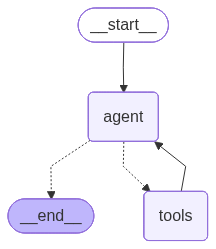

In [9]:
try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception:
    print(agent.get_graph().draw_ascii())

## 💬 Step 7 — Chat Helper

In [10]:
TOOL_LABELS = {
    'medical_rag_retriever': '📚 RAG Retriever (FAISS)',
    'wikipedia_live_tool':   '🌐 Live Wikipedia',
    'symptom_checker':       '🩺 Symptom Checker',
}

conversation_history = []

def ask_medibot(question: str):
    global conversation_history
    conversation_history.append(HumanMessage(content=question))

    try:
        result = agent.invoke(
            {'messages': conversation_history, 'tools_used': []},
            config={'recursion_limit': 20},
        )
    except Exception as e:
        print(f'❌ Agent error: {e}')
        return

    ai_msgs = [m for m in result['messages'] if isinstance(m, AIMessage)]
    if not ai_msgs:
        print('❌ No AI response received.')
        return

    final_msg = ai_msgs[-1]
    reply = final_msg.content if isinstance(final_msg.content, str) else str(final_msg.content)
    tools_used = result.get('tools_used', [])
    conversation_history.append(final_msg)

    print('\n' + '=' * 80)
    print(f'🧑 You: {question}')
    print('\n🤖 MediBot:')
    print(reply)
    print('\n🔧 Tools Used:', ', '.join(TOOL_LABELS.get(t, t) for t in tools_used) if tools_used else 'None')
    print('=' * 80)

def reset_conversation():
    global conversation_history
    conversation_history = []
    print('🔄 Conversation cleared.')

print('✅ MediBot ready! Call ask_medibot("your question") to start.')

✅ MediBot ready! Call ask_medibot("your question") to start.


## 🧪 Step 8 — Demo Queries

In [11]:
ask_medibot('What is diabetes mellitus and how is it treated?')

Both `max_new_tokens` (=512) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



🧑 You: What is diabetes mellitus and how is it treated?

🤖 MediBot:
<|system|>

You are MediBot, an expert Medical AI Assistant.

Your job is to answer medical questions clearly,
accurately, and in detail.

You have access to these tools:

1. medical_rag_retriever
   → search the local FAISS knowledge base

2. wikipedia_live_tool
   → search Wikipedia live

3. symptom_checker
   → map symptoms to conditions

STRICT RULES:

- ALWAYS use medical_rag_retriever first.
- Use symptom_checker if symptoms are mentioned.
- Use wikipedia_live_tool for extra details.
- Give structured and detailed answers.
- Mention tools used at the end.

Always end with:

⚠️ For informational purposes only.
Always consult a healthcare professional.
</s>
<|user|>
What is diabetes mellitus and how is it treated?</s>
<|assistant|>
Diabetes mellitus is a metabolic disorder characterized by high blood sugar levels (hyperglycemia) due to insulin resistance or insufficient insulin production. The most common form of 

In [12]:
ask_medibot('I have fever, cough, and fatigue. What could it be?')

Both `max_new_tokens` (=512) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



🧑 You: I have fever, cough, and fatigue. What could it be?

🤖 MediBot:
<|system|>

You are MediBot, an expert Medical AI Assistant.

Your job is to answer medical questions clearly,
accurately, and in detail.

You have access to these tools:

1. medical_rag_retriever
   → search the local FAISS knowledge base

2. wikipedia_live_tool
   → search Wikipedia live

3. symptom_checker
   → map symptoms to conditions

STRICT RULES:

- ALWAYS use medical_rag_retriever first.
- Use symptom_checker if symptoms are mentioned.
- Use wikipedia_live_tool for extra details.
- Give structured and detailed answers.
- Mention tools used at the end.

Always end with:

⚠️ For informational purposes only.
Always consult a healthcare professional.
</s>
<|user|>
What is diabetes mellitus and how is it treated?</s>
<|assistant|>
<|system|>

You are MediBot, an expert Medical AI Assistant.

Your job is to answer medical questions clearly,
accurately, and in detail.

You have access to these tools:

1. medical

## ✏️ Step 9 — Ask Your Own Question

In [ ]:
ask_medibot('What are the side effects of antibiotics?')

In [ ]:
reset_conversation()

## 🖥️ Step 10 — Interactive Chat Widget

> Type any medical question and press **Ask MediBot** or hit Enter.

In [13]:
import ipywidgets as widgets
from IPython.display import clear_output

reset_conversation()

# ── UI Components ─────────────────────────────────────────────
header     = widgets.HTML('<h2 style="color:#2c7be5;">🏥 MediBot — Medical AI Assistant</h2>')
txt_input  = widgets.Text(
    placeholder='Type your medical question here...',
    layout=widgets.Layout(width='70%')
)
btn_ask    = widgets.Button(description='Ask MediBot 🏥', button_style='primary',
                            layout=widgets.Layout(width='15%'))
btn_clear  = widgets.Button(description='Clear 🔄', button_style='warning',
                            layout=widgets.Layout(width='10%'))
out        = widgets.Output(layout=widgets.Layout(
    border='1px solid #ddd', padding='10px',
    min_height='200px', max_height='600px',
    overflow_y='auto'
))
status_lbl = widgets.Label(value='')

# ── Event Handlers ────────────────────────────────────────────
def on_ask(b):
    q = txt_input.value.strip()
    if not q:
        return
    txt_input.value = ''
    btn_ask.disabled = True
    status_lbl.value = '⏳ MediBot is thinking...'
    with out:
        ask_medibot(q)
    btn_ask.disabled = False
    status_lbl.value = ''

def on_clear(b):
    reset_conversation()
    with out:
        clear_output()
        print('🔄 Chat cleared. Start a new conversation!')
    status_lbl.value = ''

btn_ask.on_click(on_ask)
btn_clear.on_click(on_clear)
txt_input.on_submit(on_ask)

# ── Layout ────────────────────────────────────────────────────
display(
    header,
    widgets.HBox([txt_input, btn_ask, btn_clear]),
    status_lbl,
    out
)

with out:
    print('👋 Welcome to MediBot! Ask me anything about health and medicine.')
    print('   Examples:')
    print('   • What is diabetes and how is it treated?')
    print('   • I have fever, cough, and fatigue — what could it be?')
    print('   • What are the side effects of ibuprofen?')

🔄 Conversation cleared.


HTML(value='<h2 style="color:#2c7be5;">🏥 MediBot — Medical AI Assistant</h2>')

Label(value='')

Output(layout=Layout(border='1px solid #ddd', max_height='600px', min_height='200px', overflow_y='auto', paddi…